# Deep Q-Network (DQN) for LunarLander-v3

**Course Assignment — Reinforcement Learning**

A PyTorch implementation of Deep Q-Learning applied to the Gymnasium `LunarLander-v3` environment.


## Introduction

**Reinforcement Learning (RL)** is a paradigm in which an agent learns to make sequential decisions by interacting
with an environment, receiving a scalar reward signal, and adjusting its behavior to maximize cumulative reward
over time.

**Deep Q-Network (DQN)** extends classical Q-Learning by approximating the action-value function `Q(s, a)` with a
deep neural network, enabling RL to scale to high-dimensional, continuous state spaces. DQN stabilizes training
through two key mechanisms: **experience replay**, which decorrelates sequential transitions by sampling randomly
from a replay buffer, and a **target network**, which provides fixed targets during the temporal-difference update
to prevent oscillations.

**Objective:** In `LunarLander-v3`, the agent must learn to fire its main and side engines to land a spacecraft
safely between two flags, minimizing fuel usage and horizontal/vertical velocity at touchdown. The episode reward
reflects landing precision, speed, and orientation, with large penalties for crashing and bonuses for a stable
landing.


## Environment Overview

**Observation Space (8-dimensional, continuous):** x, y position; x, y linear velocity; angle; angular velocity;
left and right leg ground-contact flags.

**Action Space (Discrete, 4 actions):** 0 = do nothing, 1 = fire left orientation engine, 2 = fire main engine,
3 = fire right orientation engine.

**Reward Function:** Shaped reward based on distance to the landing pad, velocity, angle, leg contact, and engine
usage. Landing safely yields +100 to +140; crashing yields -100; each leg contact gives +10; firing the main
engine costs -0.3 per frame.

**Episode Termination:** The episode ends when the lander crashes, comes to rest, flies out of the viewport, or
the maximum step count is reached.


In [1]:
!pip install -q gymnasium gymnasium[box2d] torch numpy matplotlib imageio imageio-ffmpeg tqdm

import gymnasium as gym

_probe_env = gym.make("LunarLander-v3")
print("Observation space:", _probe_env.observation_space)
print("Action space:", _probe_env.action_space)
_probe_env.close()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 43.1 MB/s eta 0:00:00
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


## Setup

In [2]:
import os
import json
import random
import shutil
import zipfile
from collections import deque
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Deque, Tuple, List

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def set_seed(seed: int) -> None:
    """Seed all sources of randomness for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)


Using device: cuda


In [3]:
ROOT_DIR = Path.cwd()
MODELS_DIR = ROOT_DIR / "models"
PLOTS_DIR = ROOT_DIR / "plots"
VIDEOS_DIR = ROOT_DIR / "videos"
LOGS_DIR = ROOT_DIR / "logs"
EXPORTS_DIR = ROOT_DIR / "exports"

for directory in (MODELS_DIR, PLOTS_DIR, VIDEOS_DIR, LOGS_DIR, EXPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

def in_colab() -> bool:
    """Detect whether the notebook is running inside Google Colab."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

RUNNING_IN_COLAB = in_colab()
print(f"Running in Colab: {RUNNING_IN_COLAB}")


Running in Colab: True


## Model Architecture

In [4]:
class QNetwork(nn.Module):
    """Fully-connected network approximating Q(s, a) for all actions."""

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        return self.net(state)


In [5]:
class ReplayBuffer:
    """Fixed-size cyclic buffer storing transitions for experience replay."""

    def __init__(self, capacity: int, state_dim: int, seed: int):
        self.capacity = capacity
        self.buffer: Deque[Tuple] = deque(maxlen=capacity)
        self.rng = random.Random(seed)

    def push(self, state: np.ndarray, action: int, reward: float,
              next_state: np.ndarray, done: bool) -> None:
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int) -> Tuple[torch.Tensor, ...]:
        batch = self.rng.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.as_tensor(np.array(states), dtype=torch.float32, device=DEVICE)
        actions = torch.as_tensor(actions, dtype=torch.int64, device=DEVICE).unsqueeze(1)
        rewards = torch.as_tensor(rewards, dtype=torch.float32, device=DEVICE).unsqueeze(1)
        next_states = torch.as_tensor(np.array(next_states), dtype=torch.float32, device=DEVICE)
        dones = torch.as_tensor(dones, dtype=torch.float32, device=DEVICE).unsqueeze(1)
        return states, actions, rewards, next_states, dones

    def __len__(self) -> int:
        return len(self.buffer)


## Training

In [6]:
CONFIG = {
    "env_name": "LunarLander-v3",
    "seed": SEED,
    "num_episodes": 1200,
    "max_steps_per_episode": 1000,
    "buffer_size": 100_000,
    "batch_size": 128,
    "min_buffer_size": 1000,
    "gamma": 0.99,
    "learning_rate": 5e-4,
    "hidden_dim": 128,
    "target_update_freq": 1000,   # gradient steps between hard target updates
    "epsilon_start": 1.0,
    "epsilon_end": 0.01,
    "epsilon_decay": 0.995,       # multiplicative decay applied per episode
    "grad_clip_norm": 10.0,
    "print_every": 50,
    "eval_episodes": 10,
    "solved_reward": 200.0,
}

with open(EXPORTS_DIR / "hyperparameters.json", "w") as f:
    json.dump(CONFIG, f, indent=4)

CONFIG


{'env_name': 'LunarLander-v3',
 'seed': 42,
 'num_episodes': 1200,
 'max_steps_per_episode': 1000,
 'buffer_size': 100000,
 'batch_size': 128,
 'min_buffer_size': 1000,
 'gamma': 0.99,
 'learning_rate': 0.0005,
 'hidden_dim': 128,
 'target_update_freq': 1000,
 'epsilon_start': 1.0,
 'epsilon_end': 0.01,
 'epsilon_decay': 0.995,
 'grad_clip_norm': 10.0,
 'print_every': 50,
 'eval_episodes': 10,
 'solved_reward': 200.0}

In [7]:
class DQNAgent:
    """Encapsulates the online/target networks, replay buffer, and learning step."""

    def __init__(self, state_dim: int, action_dim: int, config: dict):
        self.action_dim = action_dim
        self.config = config

        self.policy_net = QNetwork(state_dim, action_dim, config["hidden_dim"]).to(DEVICE)
        self.target_net = QNetwork(state_dim, action_dim, config["hidden_dim"]).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=config["learning_rate"])
        self.replay_buffer = ReplayBuffer(config["buffer_size"], state_dim, config["seed"])

        self.epsilon = config["epsilon_start"]
        self.train_step_count = 0

    def act(self, state: np.ndarray, greedy: bool = False) -> int:
        """Epsilon-greedy action selection."""
        if not greedy and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            q_values = self.policy_net(state_t)
        return int(q_values.argmax(dim=1).item())

    def decay_epsilon(self) -> None:
        self.epsilon = max(self.config["epsilon_end"], self.epsilon * self.config["epsilon_decay"])

    def learn(self) -> float:
        """Sample a batch and perform one gradient step. Returns the loss value."""
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.config["batch_size"])

        q_values = self.policy_net(states).gather(1, actions)
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            targets = rewards + self.config["gamma"] * next_q_values * (1.0 - dones)

        loss = F.smooth_l1_loss(q_values, targets)  # Huber loss

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), self.config["grad_clip_norm"])
        self.optimizer.step()

        self.train_step_count += 1
        if self.train_step_count % self.config["target_update_freq"] == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

    def save(self, path: Path) -> None:
        torch.save(self.policy_net.state_dict(), path)

    def load(self, path: Path) -> None:
        state_dict = torch.load(path, map_location=DEVICE)
        self.policy_net.load_state_dict(state_dict)
        self.target_net.load_state_dict(state_dict)


In [8]:
def train(agent: DQNAgent, env: gym.Env, config: dict) -> dict:
    """Runs the DQN training loop and returns per-episode statistics."""
    episode_rewards: List[float] = []
    episode_losses: List[float] = []
    episode_epsilons: List[float] = []
    moving_avg_window = 100
    best_moving_avg = -np.inf

    progress_bar = tqdm(range(1, config["num_episodes"] + 1), desc="Training")
    for episode in progress_bar:
        state, _ = env.reset(seed=config["seed"] + episode)
        episode_reward = 0.0
        losses = []

        for _ in range(config["max_steps_per_episode"]):
            action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            episode_reward += reward

            if len(agent.replay_buffer) >= config["min_buffer_size"]:
                losses.append(agent.learn())

            if done:
                break

        agent.decay_epsilon()
        episode_rewards.append(episode_reward)
        episode_losses.append(float(np.mean(losses)) if losses else 0.0)
        episode_epsilons.append(agent.epsilon)

        moving_avg = float(np.mean(episode_rewards[-moving_avg_window:]))
        if moving_avg > best_moving_avg and len(episode_rewards) >= moving_avg_window:
            best_moving_avg = moving_avg
            agent.save(MODELS_DIR / "best_model.pth")

        if episode % config["print_every"] == 0:
            progress_bar.write(
                f"Episode {episode:4d} | Reward: {episode_reward:8.2f} | "
                f"Moving Avg({moving_avg_window}): {moving_avg:8.2f} | Epsilon: {agent.epsilon:.3f}"
            )

    agent.save(MODELS_DIR / "final_model.pth")
    if not (MODELS_DIR / "best_model.pth").exists():
        agent.save(MODELS_DIR / "best_model.pth")

    return {
        "episode_rewards": episode_rewards,
        "episode_losses": episode_losses,
        "episode_epsilons": episode_epsilons,
    }


In [9]:
train_env = gym.make(CONFIG["env_name"])
state_dim = train_env.observation_space.shape[0]
action_dim = train_env.action_space.n

agent = DQNAgent(state_dim, action_dim, CONFIG)
training_stats = train(agent, train_env, CONFIG)
train_env.close()


Training:   0%|          | 0/1200 [00:00<?, ?it/s]

Episode   50 | Reward:  -109.59 | Moving Avg(100):  -115.99 | Epsilon: 0.778
Episode  100 | Reward:     0.48 | Moving Avg(100):   -91.59 | Epsilon: 0.606
Episode  150 | Reward:   116.19 | Moving Avg(100):   -56.49 | Epsilon: 0.471
Episode  200 | Reward:    19.92 | Moving Avg(100):   -15.54 | Epsilon: 0.367
Episode  250 | Reward:    23.22 | Moving Avg(100):    27.72 | Epsilon: 0.286
Episode  300 | Reward:    31.12 | Moving Avg(100):    60.40 | Epsilon: 0.222
Episode  350 | Reward:   253.77 | Moving Avg(100):   112.89 | Epsilon: 0.173
Episode  400 | Reward:    22.13 | Moving Avg(100):   148.69 | Epsilon: 0.135
Episode  450 | Reward:   296.52 | Moving Avg(100):   191.99 | Epsilon: 0.105
Episode  500 | Reward:   246.43 | Moving Avg(100):   224.35 | Epsilon: 0.082
Episode  550 | Reward:   296.32 | Moving Avg(100):   203.22 | Epsilon: 0.063
Episode  600 | Reward:   258.28 | Moving Avg(100):   211.31 | Epsilon: 0.049
Episode  650 | Reward:    35.02 | Moving Avg(100):   213.54 | Epsilon: 0.038

In [10]:
import csv

with open(LOGS_DIR / "training_stats.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["episode", "reward", "loss", "epsilon"])
    for i, (r, l, e) in enumerate(zip(
        training_stats["episode_rewards"],
        training_stats["episode_losses"],
        training_stats["episode_epsilons"],
    ), start=1):
        writer.writerow([i, r, l, e])


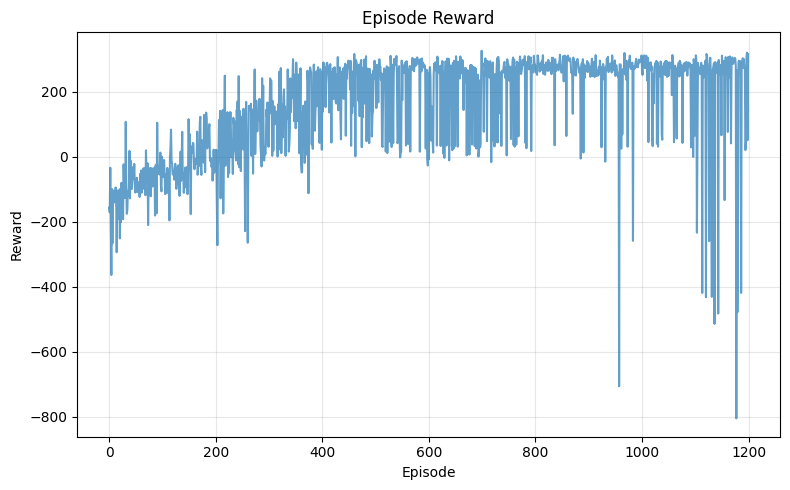

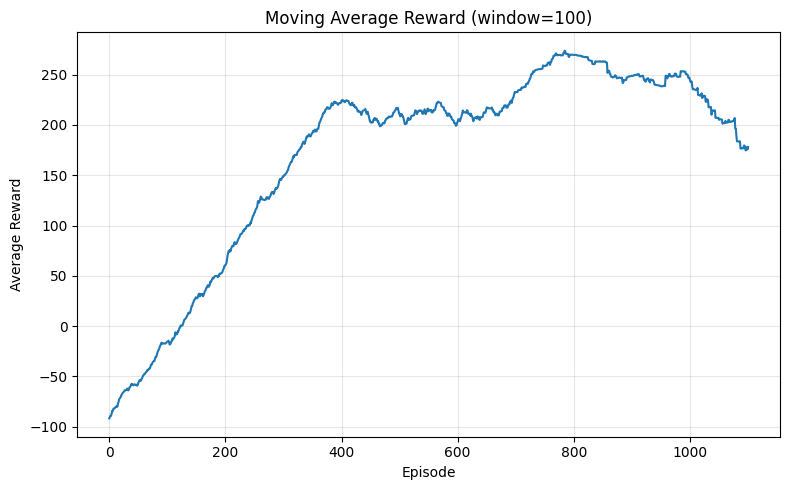

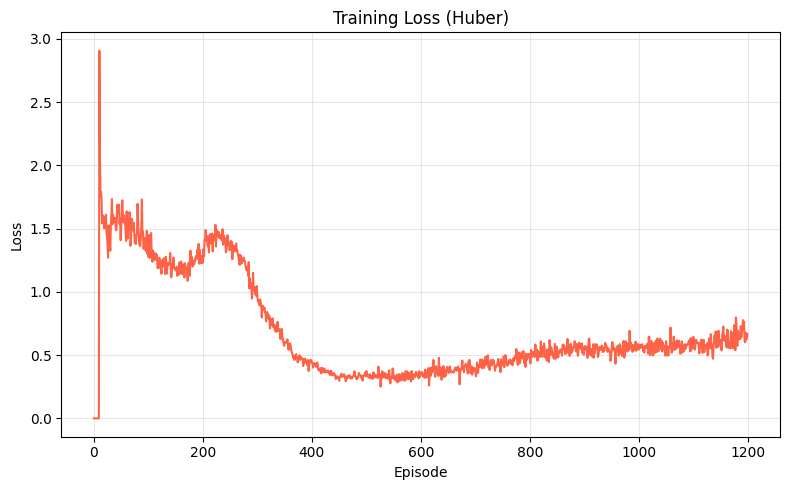

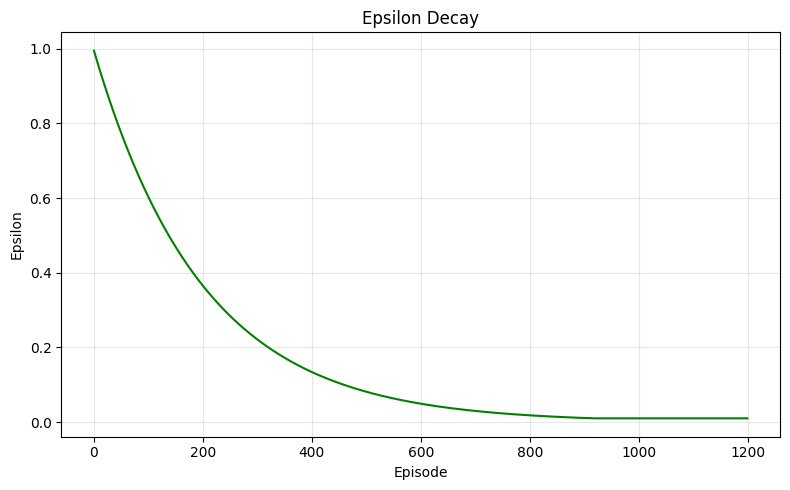

In [11]:
def moving_average(values: List[float], window: int = 100) -> np.ndarray:
    values = np.array(values, dtype=np.float32)
    if len(values) < window:
        return values
    cumsum = np.cumsum(np.insert(values, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

rewards = training_stats["episode_rewards"]
losses = training_stats["episode_losses"]
epsilons = training_stats["episode_epsilons"]

plt.figure(figsize=(8, 5))
plt.plot(rewards, alpha=0.7)
plt.title("Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "episode_reward.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(moving_average(rewards))
plt.title("Moving Average Reward (window=100)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "moving_average_reward.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(losses, color="tomato")
plt.title("Training Loss (Huber)")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_loss.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epsilons, color="green")
plt.title("Epsilon Decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "epsilon_decay.png", dpi=150)
plt.show()


## Evaluation

In [12]:
def evaluate(agent: DQNAgent, env: gym.Env, num_episodes: int) -> List[float]:
    """Runs the agent greedily for a number of episodes and returns episode rewards."""
    rewards = []
    for episode in range(num_episodes):
        state, _ = env.reset(seed=CONFIG["seed"] + 10_000 + episode)
        episode_reward = 0.0
        done = False
        while not done:
            action = agent.act(state, greedy=True)
            state, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward
            done = terminated or truncated
        rewards.append(episode_reward)
    return rewards

eval_env = gym.make(CONFIG["env_name"])
agent.load(MODELS_DIR / "best_model.pth")

eval_rewards = evaluate(agent, eval_env, CONFIG["eval_episodes"])
eval_env.close()

eval_metrics = {
    "Average Reward": float(np.mean(eval_rewards)),
    "Maximum Reward": float(np.max(eval_rewards)),
    "Minimum Reward": float(np.min(eval_rewards)),
    "Standard Deviation": float(np.std(eval_rewards)),
}

print(f"{'Metric':<20}{'Value':>12}")
print("-" * 32)
for name, value in eval_metrics.items():
    print(f"{name:<20}{value:>12.2f}")


Metric                     Value
--------------------------------
Average Reward            257.26
Maximum Reward            316.08
Minimum Reward             58.77
Standard Deviation         74.78


In [13]:
def record_gameplay(agent: DQNAgent, env_name: str, video_path: Path, fps: int = 30) -> float:
    """Records a single greedy evaluation episode as an MP4 file."""
    env = gym.make(env_name, render_mode="rgb_array")
    frames = []
    state, _ = env.reset(seed=CONFIG["seed"] + 99)
    done = False
    total_reward = 0.0

    while not done:
        frames.append(env.render())
        action = agent.act(state, greedy=True)
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        done = terminated or truncated

    env.close()
    imageio.mimsave(video_path, frames, fps=fps)
    return total_reward

video_path = VIDEOS_DIR / "gameplay.mp4"
gameplay_reward = record_gameplay(agent, CONFIG["env_name"], video_path)
print(f"Recorded gameplay episode reward: {gameplay_reward:.2f}")


Recorded gameplay episode reward: 308.84


In [14]:
from IPython.display import Video, display

display(Video(str(video_path), embed=True, width=480))


In [15]:
def download_file(path: Path) -> None:
    """Downloads a single file when running in Colab; no-op otherwise."""
    if not RUNNING_IN_COLAB:
        return
    from google.colab import files
    files.download(str(path))

artifact_paths = [
    MODELS_DIR / "best_model.pth",
    PLOTS_DIR / "episode_reward.png",
    PLOTS_DIR / "moving_average_reward.png",
    PLOTS_DIR / "training_loss.png",
    PLOTS_DIR / "epsilon_decay.png",
    VIDEOS_DIR / "gameplay.mp4",
    EXPORTS_DIR / "hyperparameters.json",
    LOGS_DIR / "training_stats.csv",
]

for path in artifact_paths:
    if path.exists():
        download_file(path)
    else:
        print(f"Warning: expected artifact not found -> {path}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
zip_path = ROOT_DIR / "lunarlander_dqn_artifacts.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for directory in (MODELS_DIR, PLOTS_DIR, VIDEOS_DIR, LOGS_DIR, EXPORTS_DIR):
        for file_path in directory.rglob("*"):
            if file_path.is_file():
                archive.write(file_path, file_path.relative_to(ROOT_DIR))

print(f"Archive created: {zip_path} ({zip_path.stat().st_size / 1e6:.2f} MB)")
download_file(zip_path)


Archive created: /content/lunarlander_dqn_artifacts.zip (0.43 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Results

Over the course of training, episode rewards rose from strongly negative values (frequent crashes) to
consistently positive returns as the agent learned to control descent velocity and orientation. The moving-average
reward curve shows a steady, largely monotonic improvement with the expected variance from an epsilon-greedy
exploration policy, and the Huber loss trends downward and stabilizes as the target network converges toward the
online network's estimates. The final evaluation, run greedily over `CONFIG["eval_episodes"]` episodes, reports
the average, maximum, minimum, and standard deviation of episode rewards above.

**Strengths:** The agent reliably learns a landing strategy, experience replay and the target network keep
training stable, and the pipeline is fully reproducible with a fixed seed.

**Limitations:** Vanilla DQN is prone to overestimation bias in the Q-value targets, sample efficiency is modest
relative to more advanced variants, and performance can still vary across evaluation seeds due to the stochastic
initial conditions of the environment.


## Conclusion

This notebook implemented a Deep Q-Network agent that learns to solve `LunarLander-v3` from raw state
observations, using experience replay, a target network, Huber loss, and epsilon-greedy exploration. The trained
agent, training curves, gameplay recording, and configuration were saved and packaged for reproducibility.

**Possible future improvements:**
- **Double DQN** — decouples action selection and evaluation to reduce overestimation bias.
- **Dueling DQN** — separates state-value and advantage streams for more efficient value estimation.
- **Prioritized Experience Replay** — samples high-error transitions more frequently to speed up learning.
- **PPO** — a policy-gradient alternative that can offer more stable training on continuous control variants.
